# Text Preprocessing, Tokenization, and Sequence Padding:

### Import Libraries

In [20]:
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/sauryabhattacharya
/kaggle/input/datasets/sauryabhattacharya/npltask


### Load the dataset

In [3]:
data_path = "/kaggle/input/datasets/sauryabhattacharya/npltask/truevsfakenews.csv" 

df = pd.read_csv(data_path)

df.head()

,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


In [4]:
# check dataset

df.columns = df.columns.str.lower().str.strip()

print(df.shape)
print(df.columns)
df.head()

(20000, 2)
Index(['text', 'label'], dtype='object')


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


In [5]:
# choose text and label columns

text_col = "text"
label_col = "label"

df = df[[text_col, label_col]].dropna()

df[text_col] = df[text_col].astype(str)
df[label_col] = df[label_col].astype(str)

df.head()

,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


dataset shape: (20000, 2)
label
true    10000
fake    10000
Name: count, dtype: int64


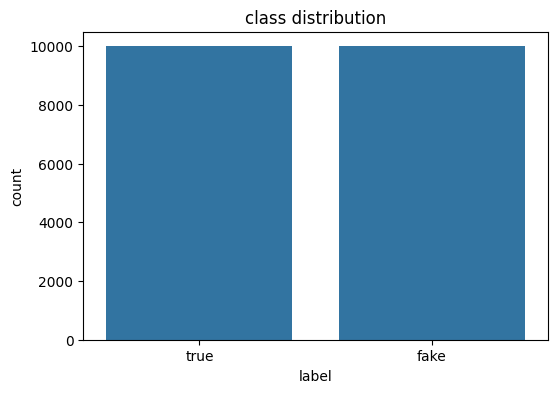

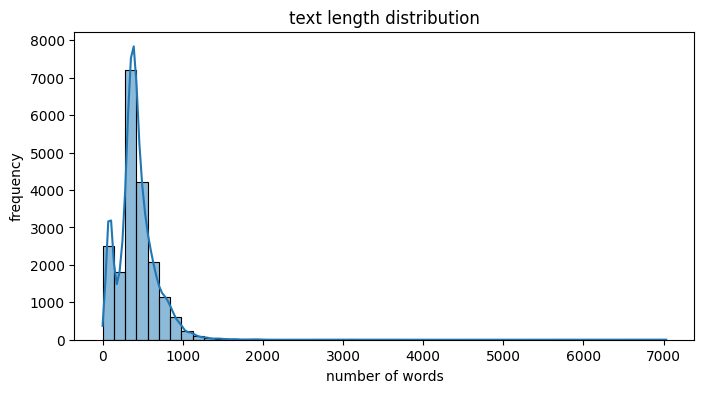

count    20000.000000
mean       426.099800
std        245.779755
min          0.000000
25%        307.000000
50%        397.500000
75%        527.000000
max       7033.000000
Name: text_length, dtype: float64

In [6]:
# dataset information

print("dataset shape:", df.shape)
print(df[label_col].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=label_col)
plt.title("class distribution")
plt.xlabel("label")
plt.ylabel("count")
plt.show()

df["text_length"] = df[text_col].apply(lambda text: len(text.split()))

plt.figure(figsize=(8, 4))
sns.histplot(df["text_length"], bins=50, kde=True)
plt.title("text length distribution")
plt.xlabel("number of words")
plt.ylabel("frequency")
plt.show()

df["text_length"].describe()

The dataset contains 20,000 records with two balanced classes: 10,000 true news descriptions and 10,000 fake news descriptions. This balanced class distribution is useful because the model receives equal examples from both classes and is less likely to become biased.

The text length distribution shows that most news descriptions are relatively short, with an average length of about 426 words. However, some descriptions are much longer, with the maximum length reaching 7,033 words. Because the text lengths vary widely, tokenization and padding are needed before training the RNN and LSTM models.

### Clean the text

In [7]:
stop_words = set(ENGLISH_STOP_WORDS)
lemmatizer = WordNetLemmatizer()

contractions = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "what's": "what is",
    "i'm": "i am",
    "you're": "you are",
    "they're": "they are",
    "we're": "we are",
    "i've": "i have",
    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",
    "you'll": "you will",
    "he'll": "he will",
    "she'll": "she will",
    "we'll": "we will",
    "they'll": "they will"
}

def clean_text(text):
    text = text.lower()
    
    for short_form, full_form in contractions.items():
        text = text.replace(short_form, full_form)
    
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

df["clean_text"] = df[text_col].apply(clean_text)

df[[text_col, "clean_text", label_col]].head()

,text,clean_text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,washington reuters republican democratic leade...,true
1,Women should get as far away from Oklahoma as ...,woman far away oklahoma soon possible christia...,fake
2,Another huge crowd of Americans tuned in last ...,huge crowd american tuned week republican held...,fake
3,Donald Trump is desperate to stop the investig...,donald trump desperate stop investigation dirt...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",reuters planned parenthood medical service pro...,true


### Visualize the cleaned data

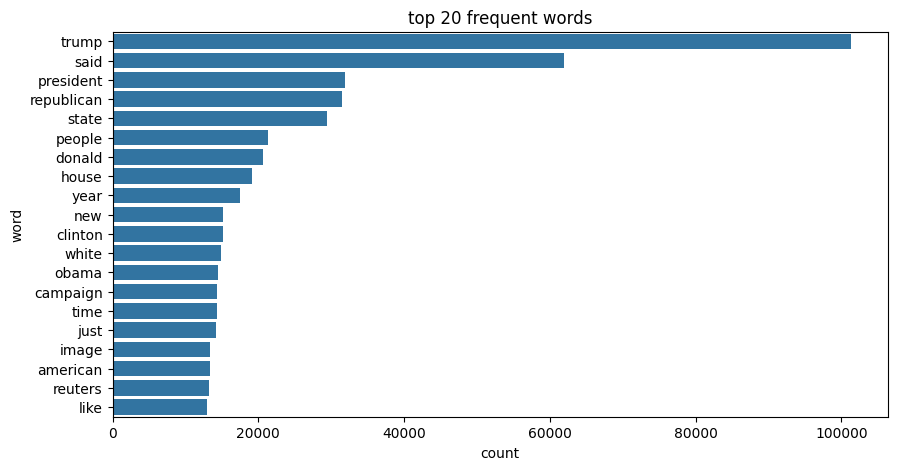

In [8]:
all_words = " ".join(df["clean_text"]).split()
word_count = Counter(all_words)

common_words = pd.DataFrame(word_count.most_common(20), columns=["word", "count"])

plt.figure(figsize=(10, 5))
sns.barplot(data=common_words, x="count", y="word")
plt.title("top 20 frequent words")
plt.show()

In [18]:
display(common_words)

,word,count
0,trump,101259
1,said,61943
2,president,31941
3,republican,31477
4,state,29488
5,people,21271
6,donald,20685
7,house,19177
8,year,17444
9,new,15170


The cleaned text visualization shows the top 20 most frequent words in the dataset. Words such as “trump”, “said”, “president”, “republican”, and “state” appear most often, which indicates that many news descriptions are related to politics and government. This also shows that the dataset contains repeated political terms, names, and news-related vocabulary, which are important features for the fake news classification task.

### Tokenization and Padding

In [9]:
# encode labels

label_encoder = LabelEncoder()

df["encoded_label"] = label_encoder.fit_transform(df[label_col])

print(label_encoder.classes_)
print(df[[label_col, "encoded_label"]].drop_duplicates())

['fake' 'true']
  label  encoded_label
0  true              1
1  fake              0


In [10]:
# train test split

x = df["clean_text"]
y = df["encoded_label"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("training data:", len(x_train))
print("testing data:", len(x_test))

training data: 16000
testing data: 4000


The dataset was split into training and testing sets using an 80:20 ratio. Out of 20,000 total records, 16,000 records were used for training and 4,000 records were used for testing. Stratified splitting was applied so that both true and fake news classes kept the same class distribution in the training and testing sets.

In [11]:
# tokenization and padding

vocab_size = 20000
embedding_dim = 100
oov_token = "<oov>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

seq_lengths = [len(seq) for seq in x_train_seq]
max_len = int(np.percentile(seq_lengths, 95))

print("padding length:", max_len)

x_train_pad = pad_sequences(
    x_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

x_test_pad = pad_sequences(
    x_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print(x_train_pad.shape)
print(x_test_pad.shape)

padding length: 456
(16000, 456)
(4000, 456)


# Model Building and  Training

**Helper Function**

In [12]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train accuracy")
    plt.plot(history.history["val_accuracy"], label="validation accuracy")
    plt.title(title + " accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="validation loss")
    plt.title(title + " loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    
    plt.show()

### Simple RNN with a trainable Embedding layer

In [21]:
embedding_dim = 128

rnn_model = keras.Sequential([
    layers.Input(shape=(max_len,)),
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),
    layers.SimpleRNN(64),
    layers.Dropout(0.4),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 456, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,574,465 (9.82 MB)

 Trainable params: 2,574,465 (9.82 MB)

 Non-trainable params: 0 (0.00 B)

**Training RNN model**

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5352 - loss: 0.6635 - val_accuracy: 0.5022 - val_loss: 0.6962
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.5171 - loss: 0.6910 - val_accuracy: 0.4969 - val_loss: 0.6812
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.5398 - loss: 0.6695 - val_accuracy: 0.5375 - val_loss: 0.6788
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.5407 - loss: 0.6642 - val_accuracy: 0.5372 - val_loss: 0.6775
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.5337 - loss: 0.6610 - val_accuracy: 0.5369 - val_loss: 0.6776
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.5444 - loss: 0.6601 - val_accuracy: 0.5378 - val_loss: 0.6774
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.5373 - loss: 0.6603 - val_accuracy: 0.5369 - val_loss: 0.6765
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5436 - loss: 0.6605 - val_accu

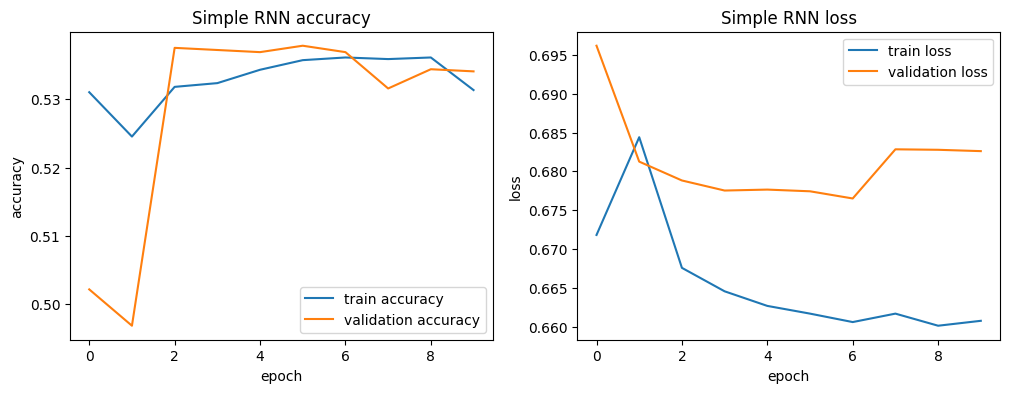

training time: 73.3795804977417


In [23]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

start_time = time.time()

rnn_history = rnn_model.fit(
    x_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop]
)

rnn_time = time.time() - start_time

plot_history(rnn_history, "Simple RNN")

print("training time:", rnn_time)

The Simple RNN graph shows low and unstable performance. Training and validation accuracy stayed around 53%, which means the model did not learn the text patterns well. The training loss decreased slightly, but validation loss stayed high, showing weak generalization.

Training stopped at epoch 10 because EarlyStopping was used. The validation loss did not improve for 3 continuous epochs, so training stopped automatically.

### LSTM with a trainable Embedding layer

In [24]:
lstm_model = keras.Sequential([
    layers.Input(shape=(max_len,)),
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),
    layers.LSTM(64),
    layers.Dropout(0.4),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

lstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 456, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,521 (9.96 MB)

 Trainable params: 2,611,521 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

**Training LSTM model**

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5145 - loss: 0.6918 - val_accuracy: 0.5381 - val_loss: 0.6752
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5256 - loss: 0.6736 - val_accuracy: 0.5384 - val_loss: 0.6754
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5505 - loss: 0.6644 - val_accuracy: 0.5412 - val_loss: 0.6744
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5396 - loss: 0.6661 - val_accuracy: 0.5403 - val_loss: 0.6887
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5477 - loss: 0.6651 - val_accuracy: 0.5437 - val_loss: 0.6846
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5710 - loss: 0.6485 - val_accuracy: 0.9584 - val_loss: 0.1291
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9706 - loss: 0.1127 - val_accuracy: 0.9712 - val_loss: 0.1138
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9918 - loss: 0.0342 - val_accu

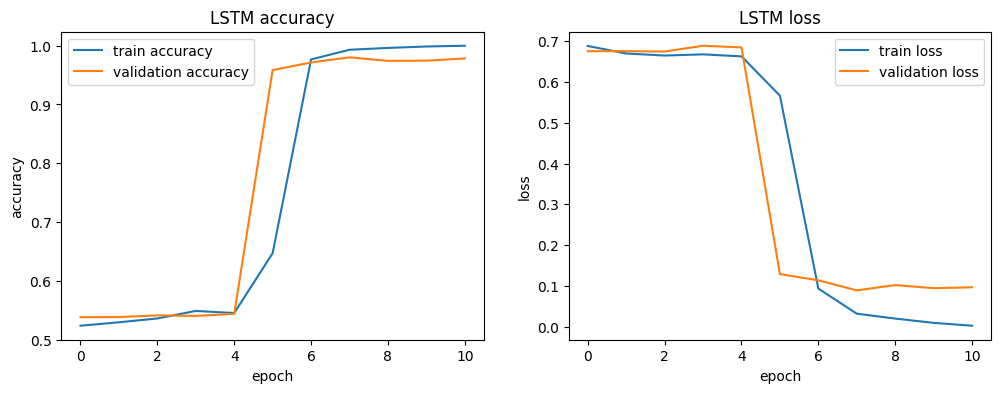

training time: 47.67452383041382


In [25]:
start_time = time.time()

lstm_history = lstm_model.fit(
    x_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop]
)

lstm_time = time.time() - start_time

plot_history(lstm_history, "LSTM")

print("training time:", lstm_time)

The LSTM graph shows a strong improvement after epoch 5. Training and validation accuracy both increased quickly, while training and validation loss decreased. This means the LSTM learned the text patterns well and generalized better than the other models.

Training stopped at epoch 11 because EarlyStopping was used. The validation loss stopped improving for 3 continuous epochs, so training ended automatically to avoid overfitting.

### LSTM with pretrained Word2Vec embeddings

**Load Word2Vec**

In [26]:
try:
    import gensim.downloader as api
except:
    !pip install gensim -q
    import gensim.downloader as api

word2vec_model = api.load("word2vec-google-news-300")

word2vec_dim = 300
word_index = tokenizer.word_index
num_words = min(vocab_size, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, word2vec_dim))

for word, index in word_index.items():
    if index >= vocab_size:
        continue
    
    if word in word2vec_model:
        embedding_matrix[index] = word2vec_model[word]

print(embedding_matrix.shape)

[===========---------------------------------------] 22.9% 381.4/1662.8MB downloaded
(20000, 300)


In [27]:
word2vec_lstm_model = keras.Sequential([
    layers.Input(shape=(max_len,)),
    layers.Embedding(
        input_dim=num_words,
        output_dim=word2vec_dim,
        weights=[embedding_matrix],
        trainable=False
    ),
    layers.LSTM(64),
    layers.Dropout(0.4),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

word2vec_lstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

word2vec_lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 456, 300)       │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,095,553 (23.25 MB)

 Trainable params: 95,553 (373.25 KB)

 Non-trainable params: 6,000,000 (22.89 MB)

**Train Word2Vec embeddings**

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5548 - loss: 0.6780 - val_accuracy: 0.5425 - val_loss: 0.6781
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5292 - loss: 0.6784 - val_accuracy: 0.5447 - val_loss: 0.6715
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5378 - loss: 0.6752 - val_accuracy: 0.5516 - val_loss: 0.6658
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6900 - loss: 0.5806 - val_accuracy: 0.9091 - val_loss: 0.2662
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9220 - loss: 0.2479 - val_accuracy: 0.9484 - val_loss: 0.1906
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9449 - loss: 0.2059 - val_accuracy: 0.8953 - val_loss: 0.2880
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8914 - loss: 0.2944 - val_accuracy: 0.5006 - val_loss: 0.6808
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5249 - loss: 0.6806 - val_accu

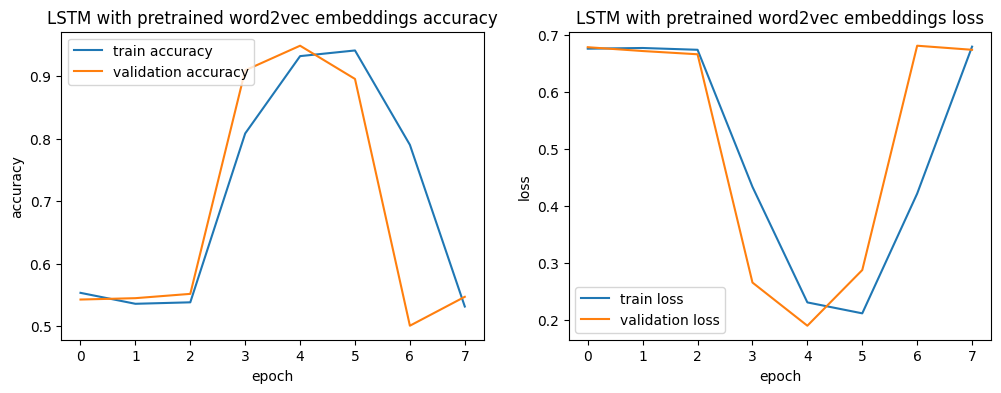

training time: 32.79412007331848


In [28]:
start_time = time.time()

word2vec_history = word2vec_lstm_model.fit(
    x_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop]
)

word2vec_time = time.time() - start_time

plot_history(word2vec_history, "LSTM with pretrained word2vec embeddings")

print("training time:", word2vec_time)

The graph shows that the Word2Vec LSTM improved until around epoch 5, but after that the validation accuracy dropped and validation loss increased. This means the model started performing worse on unseen validation data.

Training stopped at epoch 8 because EarlyStopping was used. Since validation loss did not improve for 3 continuous epochs, the training stopped automatically to prevent overfitting.

# Model Training and Evaluation

In [29]:
def evaluate_model(model, x_test_pad, y_test, model_name):
    y_prob = model.predict(x_test_pad)
    y_pred = (y_prob > 0.5).astype("int32").reshape(-1)
    
    acc = accuracy_score(y_test, y_pred)
    
    print(model_name, "accuracy:", acc)
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(model_name + " confusion matrix")
    plt.xlabel("predicted")
    plt.ylabel("actual")
    plt.show()
    
    return acc, y_pred

**Evaluate RNN model**

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
simple rnn accuracy: 0.53725
              precision    recall  f1-score   support

        fake       0.52      0.99      0.68      2000
        true       0.88      0.09      0.16      2000

    accuracy                           0.54      4000
   macro avg       0.70      0.54      0.42      4000
weighted avg       0.70      0.54      0.42      4000



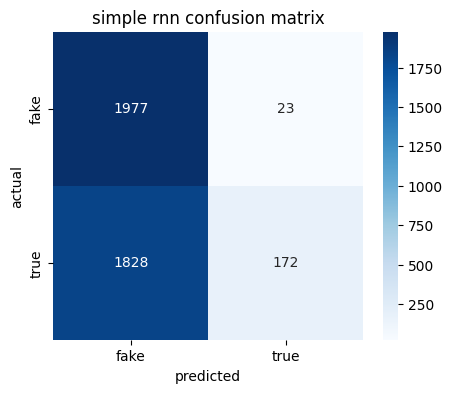

In [30]:
rnn_acc, rnn_pred = evaluate_model(
    rnn_model, 
    x_test_pad, 
    y_test, 
    "simple rnn")

The Simple RNN achieved low accuracy of 53.72%. It predicted most samples as fake, correctly classifying 1,977 fake news records but misclassifying 1,828 true news records as fake. This shows that the Simple RNN did not learn the patterns well and performed poorly on the true class.

**Evaluate LSTM model**

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
lstm accuracy: 0.9815
              precision    recall  f1-score   support

        fake       0.99      0.98      0.98      2000
        true       0.98      0.99      0.98      2000

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



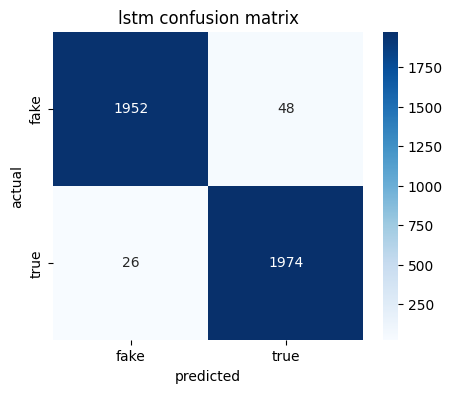

In [31]:
lstm_acc, lstm_pred = evaluate_model(
    lstm_model, 
    x_test_pad, 
    y_test, 
    "lstm")

The LSTM achieved the accuracy of 98.15%. It correctly classified 1,952 fake news and 1,974 true news records, with only 74 total wrong predictions. The high precision, recall, and F1-score show that the LSTM performed very well for both classes.

**Evaluate LSTM model**

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
lstm with pretrained word2vec embeddings accuracy: 0.9395
              precision    recall  f1-score   support

        fake       0.98      0.90      0.94      2000
        true       0.91      0.98      0.94      2000

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000



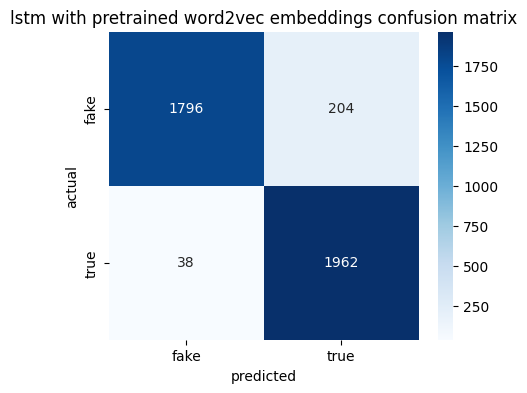

In [32]:
word2vec_acc, word2vec_pred = evaluate_model(
    word2vec_lstm_model,
    x_test_pad,
    y_test,
    "lstm with pretrained word2vec embeddings"
)

The LSTM with pretrained Word2Vec embeddings achieved 93.95% accuracy. It correctly classified 1,796 fake news and 1,962 true news records. However, it misclassified 204 fake news records as true, so it performed slightly worse than the normal LSTM model.

**Compare all models**

In [34]:
results = pd.DataFrame({
    "model": ["simple rnn", "lstm", "lstm with pretrained embeddings"],
    "accuracy": [rnn_acc, lstm_acc, word2vec_acc],
    "training_time": [rnn_time, lstm_time, word2vec_time]
})

results

,model,accuracy,training_time
0,simple rnn,0.53725,73.379580
1,lstm,0.98150,47.674524
2,lstm with pretrained embeddings,0.93950,32.794120


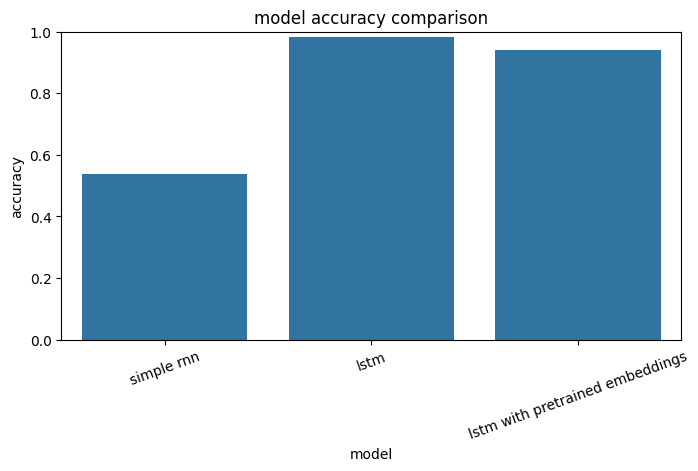

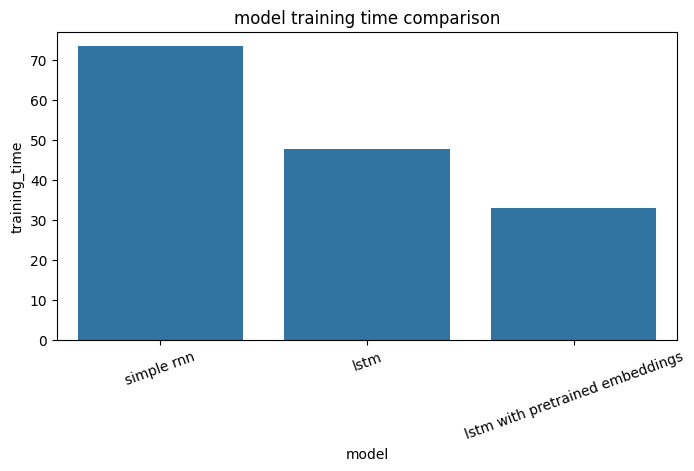

In [35]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results, x="model", y="accuracy")
plt.title("model accuracy comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=results, x="model", y="training_time")
plt.title("model training time comparison")
plt.xticks(rotation=20)
plt.show()

The model comparison shows that the LSTM model achieved the best accuracy of 0.98150, outperforming both the Simple RNN and the LSTM with pretrained embeddings. The Simple RNN had the lowest accuracy of 0.53725, showing that it was not able to learn the text patterns well. The LSTM with pretrained embeddings performed well with an accuracy of 0.93950 and also had the shortest training time. However, the normal LSTM gave the best overall performance, so it was selected as the best model for prediction and error analysis.

# Error Analysis

In [37]:
test_df = pd.DataFrame({
    "text": x_test.values,
    "actual": y_test.values,
    "predicted": lstm_pred
})

wrong_df = test_df[test_df["actual"] != test_df["predicted"]]

print("wrong predictions:", len(wrong_df))

for index, row in wrong_df.head(3).iterrows():
    print("\ntext:", row["text"][:500])
    print("actual:", label_encoder.inverse_transform([row["actual"]])[0])
    print("predicted:", label_encoder.inverse_transform([row["predicted"]])[0])

wrong predictions: 74

text: winner america president trump supreme court ruled favor travel ban guess voted justice ruth bader ginsburg sonia sotomayor said left lower court order place surprised lefty judge fox news report handing white house huge judicial victory supreme court monday ruled favor president trump travel ban affecting resident majority muslim country justice said policy effect despite multiple legal challenge haven way court ban applies people syria chad iran libya somalia yemen lower court said people coun
actual: fake
predicted: true

text: washington reuters military intelligence analyst chelsea manning thursday questioned barack obama legacy democratic president commuted sentence week called unapologetic progressive leader fight minority right mentioning president donald trump manning wrote britain guardian year attempted compromise relentless disrespect return moving darker time urged democrat compromise trump responded tweet calling traitor criticizing decision r

The error analysis was performed using the LSTM model because it achieved the best performance among the three models. The model made some incorrect predictions, which shows that even the best-performing model still struggled with certain news descriptions.

**Model Complexity VS Performance**

In terms of model complexity versus performance, the Simple RNN is the least complex model because it uses a basic recurrent layer. The LSTM model is more complex because it uses memory gates to capture longer word relationships in text. The LSTM with pretrained Word2Vec embeddings is also complex because it uses external word vectors. In this experiment, the normal LSTM performed best, which shows that the additional complexity of LSTM was useful. However, the Word2Vec LSTM did not perform better, which may be because the pretrained embeddings did not fully match the vocabulary and writing style of the fake news dataset.

**Possible reason for error**
1. True and fake news often use similar political words and names.
2. Some descriptions may be too short and lack enough context.
3. Real news can sometimes use dramatic language.
4. Fake news can sometimes look formal and realistic.
5. Text cleaning may remove useful signals like numbers or punctuation.


**Potential improvements**
1. Tuning LSTM units, dropout rate, batch size, and learning rate.
2. Trying Bidirectional LSTM or GRU models.
3. Making pretrained embeddings trainable.
4. Removing duplicate or noisy records from the dataset.
5. Testing transformer models such as BERT in future work.


# GUI for Real Time Prediction

In [39]:
def predict_news(text):
    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=max_len, padding="post", truncating="post")
    
    probability = lstm_model.predict(padded)[0][0]
    predicted_class = 1 if probability > 0.5 else 0
    predicted_label = label_encoder.inverse_transform([predicted_class])[0]
    
    confidence = probability if predicted_class == 1 else 1 - probability
    
    return predicted_label, confidence

sample_text = "The government has officially announced a new economic policy today."

label, confidence = predict_news(sample_text)

print("prediction:", label)
print("confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
prediction: true
confidence: 0.96981144


This prediction function uses the best-performing LSTM model to classify new unseen news text. The input sentence was cleaned, tokenized, padded, and passed into the trained model. For the sample text, the model predicted the news as true with a confidence score of 0.9698, showing that the prediction function is working correctly.

In [40]:
try:
    import gradio as gr
except:
    !pip install gradio -q
    import gradio as gr

def app_predict(text):
    label, confidence = predict_news(text)
    return "prediction: " + str(label) + "\nconfidence: " + str(round(confidence, 4))

app = gr.Interface(
    fn=app_predict,
    inputs=gr.Textbox(lines=6, placeholder="enter news description here"),
    outputs="text",
    title="fake news detection"
)

app.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://5d8b6288c8c851afd6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


The Gradio interface successfully provides real-time fake news prediction. Here, the model predicted the input news text as fake with high confidence, showing that the real-time prediction system is working correctly.

**Conclusion**

In conclusion, this NLP task successfully built and compared three deep learning models for fake news detection: Simple RNN, LSTM, and LSTM with pretrained Word2Vec embeddings. After preprocessing, tokenization, and padding, the models were trained and evaluated using accuracy, confusion matrix, and classification report. The LSTM model achieved the best performance with 98.15% accuracy, showing that it learned the text patterns better than the other models. A Gradio interface was also created for real-time prediction, allowing users to enter news text and receive a true or fake prediction.